##Capstone Project: Same Profile, Different Outcomes - Understanding Health Differences Through a Twin Lens

This project uses the CDC BRFSS 2022 dataset to explore whether people with similar demographic profiles can still experience different health outcomes across extreme income levels.

The analysis focuses on respondents who share similar characteristics including:
- Age
- Sex
- Race/Ethnicity
- Education

Income is then used as the comparison factor by examining two extreme groups:
- Respondents earning less than \$10,000
- Respondents earning $200,000 or more

The main health outcomes analyzed in this project are:
- Fair/Poor General Health
- Current Smoking
- Alcohol Use in the Past 30 Days

## Research Questions

- How do health outcomes differ betwwen lower-income and higher-oncome individuals with otherwise similiar demographic profiles?
- Can individuals with similar characteristics still experience significantly different health outcomes?
- Did income differences appear consistently across multiple health outcomes?

## An unexpected observation
I initially included education level when matching profiles, but after reviewing the early results, I found that it wasn’t significantly impacting the comparisons. Because of that, I refined the methodology and focused on the variables that revealed clearer patterns in the data.

In [ ]:
# Importing the libraries needed for data analysis and visualization.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving LLCP2022_selected.csv to LLCP2022_selected.csv


In [ ]:
# Loading the CDC BRFSS dataset.

df = pd.read_csv('LLCP2022_selected.csv')

# Displaying the first few rows
# to confirm the dataset loaded correctly.

df.head()

,DRNKANY6,EDUCA,GENHLTH,INCOME3,SEXVAR,_SMOKGRP,_AGEG5YR,_RACEGR4
0,2.0,6.0,2.0,99.0,2.0,4.0,13.0,1.0
1,2.0,4.0,1.0,5.0,2.0,4.0,13.0,1.0
2,2.0,6.0,2.0,10.0,2.0,4.0,8.0,1.0
3,2.0,4.0,1.0,77.0,2.0,3.0,14.0,1.0
4,1.0,5.0,4.0,5.0,2.0,4.0,5.0,1.0


## Preparing the Dataset
The original CDC BRFSS 2022 dataset contained far more information than was needed for this project. To make the analysis more manageable and focused, only the variables relevent to the research questions were selected. The cleaned dataset ws then saved as LLCP2022_selected.csv, which contained approximately 445,132 rows and 8 columns used throughout the project.

Although the cleaned dataset contained 445,132 respondents, this analysis focused only on respondents in the highest and lowest income categories. After filtering the data, the final comparison included 10,298 lower-income respondents and 23,460 higher-income respondents.

This focused approached allowed for a clearer comparison of health outcomes across two extreme income groups.

In [ ]:
df.shape

(445132, 8)

In [ ]:
# Selecting only the variables needed for this project.

selected_columns = [
    'GENHLTH',
    'INCOME3',
    '_SMOKGRP',
    'DRNKANY6',
    'EDUCA',
    '_AGEG5YR',
    'SEXVAR',
    '_RACEGR4'
]

# Creating a smaller dataframe using only the selected variables.

df_selected = df[selected_columns].copy()

# Displaying the first few rows.

df_selected.head()

,GENHLTH,INCOME3,_SMOKGRP,DRNKANY6,EDUCA,_AGEG5YR,SEXVAR,_RACEGR4
0,2.0,99.0,4.0,2.0,6.0,13.0,2.0,1.0
1,1.0,5.0,4.0,2.0,4.0,13.0,2.0,1.0
2,2.0,10.0,4.0,2.0,6.0,8.0,2.0,1.0
3,1.0,77.0,3.0,2.0,4.0,14.0,2.0,1.0
4,4.0,5.0,4.0,1.0,5.0,5.0,2.0,1.0


##Data Cleaning

Before beginning the analysis, invalid or incomplete survey responses were removed from the dataset. This helped ensure that all calculations were based only on valid health responses.

In [ ]:
# Removing invalid General Health responses.

# In BRFSS:
# 1 = Excellent
# 2 = Very Good
# 3 = Good
# 4 = Fair
# 5 = Poor
# 7 = Don't know / Not sure
# 9 = Refused

# Keeping only valid responses from 1 through 5.

valid_health = df_selected[
    df_selected['GENHLTH'].isin([1, 2, 3, 4, 5])
]

# Checking the remaining values.

valid_health['GENHLTH'].value_counts().sort_index()

,count
GENHLTH,
1.0,71878
2.0,148444
3.0,143598
4.0,60273
5.0,19741


##Defining the Twin Profile

The “Twin Profile” represents people who appear similar on paper based on shared demographic characteristics.

These profiles are matched using:
- Age
- Sex
- Race/Ethnicity
- Education

Income is intentionally excluded from the matching profile because income is used later as the primary comparison factor.

In [ ]:
# Creating the demographic matching profile.

profile_columns = [
    '_AGEG5YR',
    'SEXVAR',
    '_RACEGR4',
    'EDUCA'
]

# Displaying the selected profile columns.

profile_columns

['_AGEG5YR', 'SEXVAR', '_RACEGR4', 'EDUCA']

## Creating the Extreme Income Groups

This analysis compares respondents at opposite ends of the income spectrum:
- Less than \$10,000
- $200,000 or more

In [ ]:
# Creating the lower-income group.

lower_income = valid_health[
    valid_health['INCOME3'] == 1
]

# Creating the higher-income group.

higher_income = valid_health[
    valid_health['INCOME3'] == 11
]

# Displaying the number of respondents
# in each group.

print("Lower Income Count:", len(lower_income))
print("Higher Income Count:", len(higher_income))

Lower Income Count: 10298
Higher Income Count: 23460


## General Health Analysis

This section compares the percentage of respondents reporting fair or poor general health across both income groups.

In [ ]:
# Calculating Fair/Poor General Health percentages.

# In BRFSS:
# 4 = Fair
# 5 = Poor

# Calculating the percentage for the lower-income group.

low_health_pct = (
    lower_income['GENHLTH']
    .isin([4, 5])
    .mean() * 100
)

# Calculating the percentage for the higher-income group.

high_health_pct = (
    higher_income['GENHLTH']
    .isin([4, 5])
    .mean() * 100
)

# Printing the results.

print(f"Lower Income Group Fair/Poor Health: {low_health_pct:.1f}%")
print(f"Higher Income Group Fair/Poor Health: {high_health_pct:.1f}%")

Lower Income Group Fair/Poor Health: 44.2%
Higher Income Group Fair/Poor Health: 4.9%


## Smoking Analysis

This section compares current smoking rates across both income groups.

In [ ]:
# In BRFSS:
# 1 = Everyday smoker
# 2 = Some days smoker

# Combining both categories to represent current smokers.

low_smoking_pct = (
    lower_income['_SMOKGRP']
    .isin([1, 2])
    .mean() * 100
)

high_smoking_pct = (
    higher_income['_SMOKGRP']
    .isin([1, 2])
    .mean() * 100
)

# Printing the results.

print(f"Lower Income Group Current Smokers: {low_smoking_pct:.1f}%")
print(f"Higher Income Group Current Smokers: {high_smoking_pct:.1f}%")

Lower Income Group Current Smokers: 14.9%
Higher Income Group Current Smokers: 3.0%


## Alcohol Use Analysis

This section compares alcohol use in the past 30 days across both income groups.

In [ ]:
# In BRFSS:
# 1 = Yes
# 2 = No

# Calculating alcohol use percentages.

low_alcohol_pct = (
    lower_income['DRNKANY6']
    .isin([1])
    .mean() * 100
)

high_alcohol_pct = (
    higher_income['DRNKANY6']
    .isin([1])
    .mean() * 100
)

# Printing the results.

print(f"Lower Income Group Alcohol Use: {low_alcohol_pct:.1f}%")
print(f"Higher Income Group Alcohol Use: {high_alcohol_pct:.1f}%")

Lower Income Group Alcohol Use: 29.9%
Higher Income Group Alcohol Use: 71.7%


In [ ]:
# Creating the final comparison table.

summary_results = pd.DataFrame({
    'Outcome': [
        'Fair/Poor General Health',
        'Current Smokers',
        'Alcohol Use (Past 30 Days)'
    ],
    'Lower Income (<$10K)': [
        round(low_health_pct, 1),
        round(low_smoking_pct, 1),
        round(low_alcohol_pct, 1)
    ],
    'Higher Income ($200K+)': [
        round(high_health_pct, 1),
        round(high_smoking_pct, 1),
        round(high_alcohol_pct, 1)
    ]
})

# Displaying the summary table.

summary_results

,Outcome,Lower Income (<$10K),Higher Income ($200K+)
0,Fair/Poor General Health,44.2,4.9
1,Current Smokers,14.9,3.0
2,Alcohol Use (Past 30 Days),29.9,71.7


## Key Findings

The lower-income group reported significantly worse general health outcomes and higher smoking rates compared to the higher-income group.

However, alcohol use showed the opposite pattern, with the higher-income group reporting substantially higher alcohol use in the past 30 days.

These findings suggest that health risks do not disappear as income increases. Instead, different income levels may experience different types of health-related behaviors and outcomes.

## Visualizations

Two visualizations were created to support the final analysis.

The first chart shows how demographic patterns differ between the lowest and highest income groups.

The second chart compares health outcomes across those same extreme income groups, including fair/poor general health, current smoking, and alcohol use in the past 30 days.

### Chart 1: Demographic Differences Across Income Groups

This chart examines how race/ethnicity patterns differ between respondents earning less than \$10,000 and respondents earning $200,000 or more.

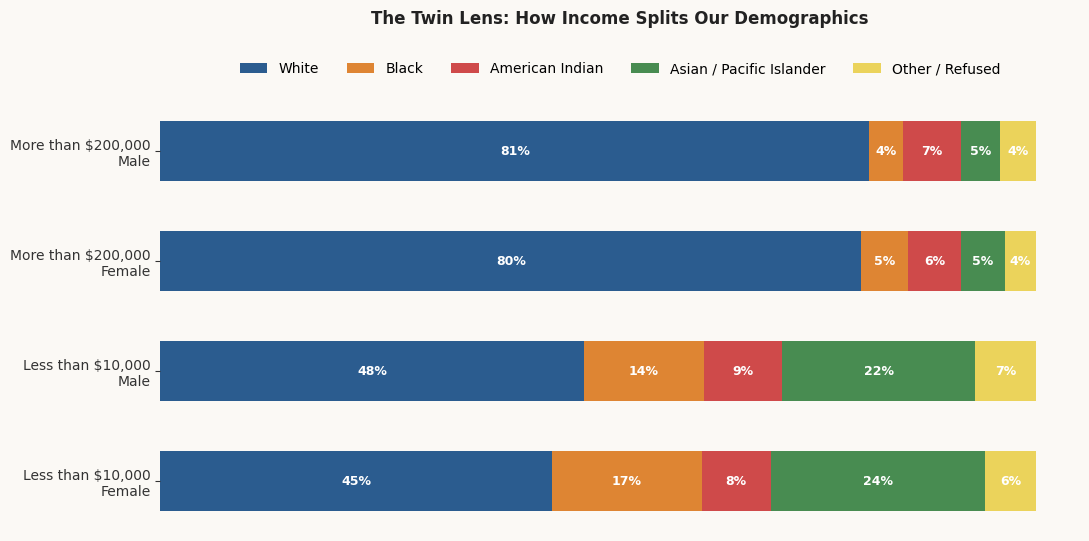

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. My data categories
categories = [
    'Less than $10,000\nFemale',
    'Less than $10,000\nMale',
    'More than $200,000\nFemale',
    'More than $200,000\nMale'
]

# 2. My exact data percentages
race_1 = np.array([44.74, 48.36, 80.00, 80.93])
race_2 = np.array([17.05, 13.69, 5.36, 3.91])
race_3 = np.array([7.92, 8.96, 6.02, 6.53])
race_5 = np.array([24.47, 22.02, 5.01, 4.54])
race_9 = np.array([5.82, 6.97, 3.61, 4.09])

# 3. Clean presentation palette matched to the ethnicity labels
colors = ['#2b5c8f', '#de8533', '#cf4a4a', '#488c51', '#ebd35b']
labels = ['White', 'Black', 'American Indian', 'Asian / Pacific Islander', 'Other / Refused']

# 4. Increased height to give the top legend breathing room
fig, ax = plt.subplots(figsize=(11, 5.5), facecolor='#fbf9f5')
ax.set_facecolor('#fbf9f5')

left_margin = np.zeros(4)
all_races = [race_1, race_2, race_3, race_5, race_9]

for i, race_data in enumerate(all_races):
    bars = ax.barh(categories, race_data, left=left_margin, color=colors[i], label=labels[i], height=0.55)
    left_margin += race_data

    for bar in bars:
        width = bar.get_width()
        # Lowered to 3.0 so smaller blocks get their numbers printed
        if width > 3.0:
            ax.text(bar.get_x() + width/2, bar.get_y() + bar.get_height()/2,
                    f'{width:.0f}%', ha='center', va='center',
                    color='white', fontweight='bold', fontsize=9)

# 5. Strip away software lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.xaxis.set_visible(False)
ax.tick_params(axis='y', colors='#333333', labelsize=10)

# 6. Moved Legend to the TOP so it is completely visible
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=5, frameon=False, fontsize=10)

# 7. Presentation Title placed cleanly below the legend
plt.text(0.5, 1.18, "The Twin Lens: How Income Splits Our Demographics",
         fontsize=12, fontweight='bold', color='#222222', ha='center', transform=ax.transAxes)

plt.tight_layout()
plt.show()


### Chart 2: Health Difference Across Income Groups

This chart compares the health differences between general health, current smokers and alcohol use in past 30 days.

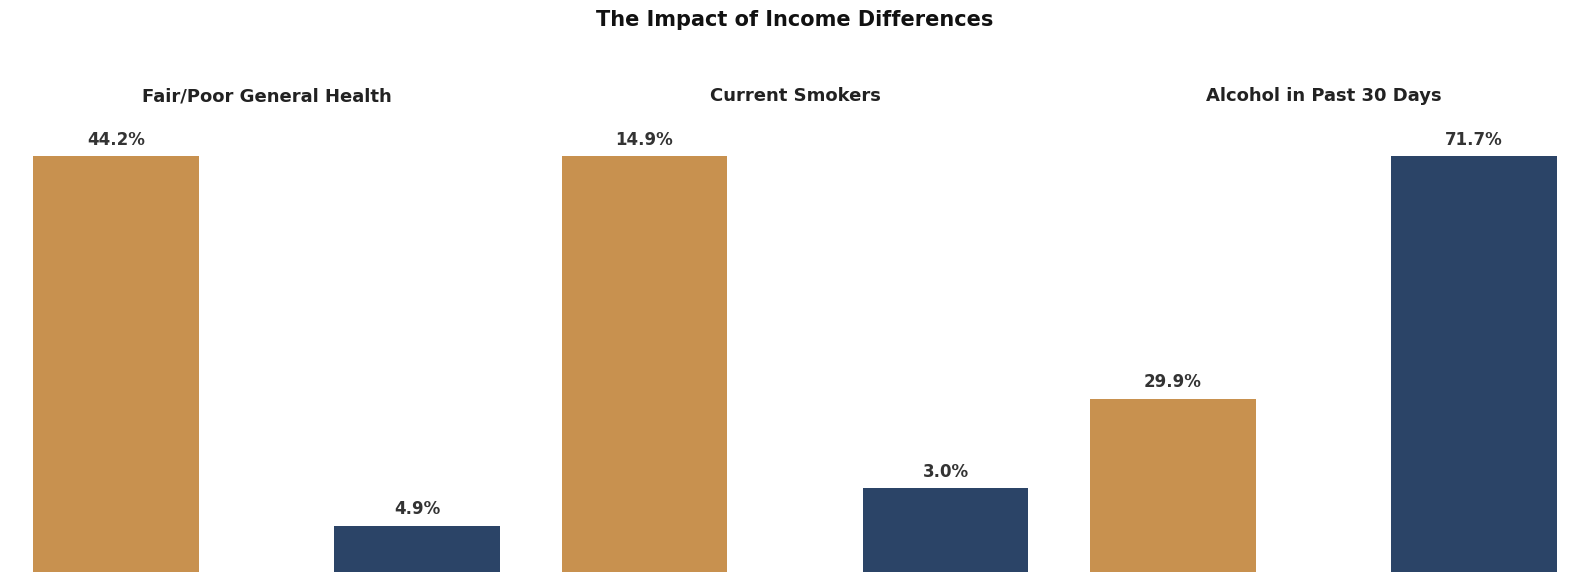

In [ ]:
# --- STEP 11: Visualizing Final Outcome Differences ---

# Importing visualization libraries.

import matplotlib.pyplot as plt
import numpy as np

# Final validated percentages from the analysis.
# Format:
# [Lower-Income Group (<$10K), Higher-Income Group ($200K+)]

poor_health_data = [44.2, 4.9]

smoking_data = [14.9, 3.0]

drinking_data = [29.9, 71.7]

# Combining all outcome categories into one list.

metrics = [
    poor_health_data,
    smoking_data,
    drinking_data
]

# Creating the chart section titles.

titles = [
    "Fair/Poor General Health",
    "Current Smokers",
    "Alcohol in Past 30 Days",
]

# Setting the bar colors.
# Orange/Tan = Lower Income Group
# Slate Blue = Higher Income Group

colors = ["#C58B45", "#1F3A5F"]

# Creating bar positions.

x_pos = np.arange(2)

# Setting the bar width.

width = 0.55

# Creating the 3-panel figure layout.

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

# Looping through each chart section.

for i, ax in enumerate(axes):

    # Selecting the current dataset.

    data = metrics[i]

    # Creating the bars.

    bars = ax.bar(
        x_pos,
        data,
        width,
        color=colors,
        edgecolor="none",
        alpha=0.95,
        zorder=2
    )

    # Adding chart section titles.

    ax.set_title(
        titles[i],
        fontsize=13,
        fontweight="bold",
        pad=25,
        color="#222222"
    )

    # Adding percentage labels above the bars.

    ax.bar_label(
        bars,
        padding=6,
        fmt="%.1f%%",
        fontsize=12,
        color="#333333",
        fontweight="bold",
    )

    # Removing x-axis labels
    # because labels are already included
    # in the presentation slide layout.

    ax.set_xticks([])
    ax.set_xticklabels([])

    # Removing y-axis numbers and ticks
    # for a cleaner infographic style.

    ax.get_yaxis().set_visible(False)

    # Removing chart borders and gridlines.

    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)

# Adding the main chart title.

plt.suptitle(
    "The Impact of Income Differences",
    fontsize=15,
    fontweight="bold",
    y=1.05,
    color="#111111",
)

# Automatically adjusting spacing.

plt.tight_layout()

# Displaying the final chart.

plt.show()

## Conclusion

This project explored how people with similar demographic profiles can still experience very different outcomes across extreme income levels.

At the beginning of this analysis, I expected the data to produce simple and predictable patterns. Instead, the deeper I went into the project, the more layered the results became.

The lower-income group reported significantly higher rates of fair or poor health and current smoking, while the higher-income group reported much higher alcohol use. These findings challenged the assumption that higher income automatically leads to healthier behaviors across every measure.

Overall, this project reinforced the idea that people may appear similar on paper, yet still experience life very differently. Behind every percentage and chart is a real person with a unique story that data alone can never fully explain.